In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [2]:

(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()


class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']



29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
print("Training images :", x_train.shape)
print("Testing images  :", x_test.shape)
print("Training labels :", y_train.shape)

Training images : (60000, 28, 28)
Testing images  : (10000, 28, 28)
Training labels : (60000,)


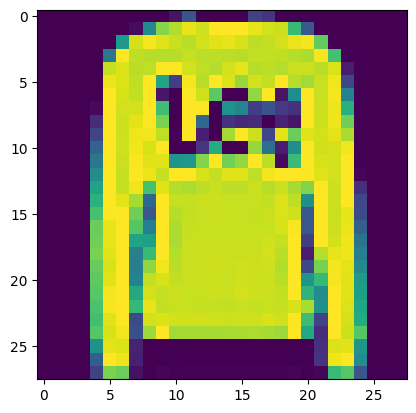

In [4]:
plt.imshow(x_test[1])

In [19]:
model = keras.Sequential([

    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(512, activation='relu'),
    # keras.layers.Dropout(0.2),

    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])



In [20]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics = ['accuracy'])

In [22]:

model.fit(x_train,y_train,epochs = 10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.7308 - loss: 5.4827
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.8306 - loss: 0.4856
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.8437 - loss: 0.4494
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.8570 - loss: 0.4074
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.8638 - loss: 0.3805
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.8705 - loss: 0.3614
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.8747 - loss: 0.3462
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.8781 - loss: 0.3413
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.8830 - loss: 0.3224
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.8817 - loss: 0.3350


In [23]:
test_accuracy, test_loss = model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8621 - loss: 0.3930


In [24]:

predictions = model.predict(x_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [25]:
print(predictions)

[[2.0811102e-16 5.0726895e-21 6.9351293e-29 ... 2.1294435e-04
  2.7881113e-13 9.9976683e-01]
 [3.3506653e-09 6.3478536e-13 9.9854559e-01 ... 4.3376263e-33
  9.1275284e-13 7.3047226e-27]
 [2.1966775e-21 9.9999994e-01 1.9300451e-22 ... 0.0000000e+00
  1.0640640e-15 1.7226518e-38]
 ...
 [4.3038248e-13 5.0391569e-19 3.0679401e-14 ... 5.6248004e-20
  9.9999994e-01 9.6507571e-15]
 [1.3140350e-21 9.9999994e-01 9.1536750e-18 ... 7.0925307e-36
  2.0583648e-12 6.8317489e-31]
 [5.4979371e-04 1.5053792e-04 4.0641502e-03 ... 9.9864639e-02
  9.6513471e-03 2.6435087e-02]]


In [26]:
print(np.argmax(predictions[10]))

4


In [27]:

model.save('second_model.h5')
loaded_model = tf.keras.models.load_model('second_model.h5')
loss, acc = loaded_model.evaluate(x_test, y_test)
print(f"Loaded Model Accuracy: {acc*100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8621 - loss: 0.3930
Loaded Model Accuracy: 86.00%
